<a href="https://colab.research.google.com/github/haniyathul/Praktikum-Analisis-Deret-Waktu/blob/main/Tugas_Kelompok_Minggu_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXPLORASI DATA DERET WAKTU
**DATA = SUHU KOTA BANDUNG**

**KELOMPOK 4**

Haniyathul Husna M0501251011

Siti Zakiah M0501251044

Viren Marcellya Clarenda Siboro M0501251047

In [7]:
#Install terlebih dahulu package PythonTsa
!pip install PythonTsa

# menginstall package pydataset
!pip install pydataset
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from PythonTsa.plot_acf_pacf import acf_pacf_fig
from pydataset import data
from statsmodels.datasets import get_rdataset

import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 45.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939458 sha256=155e2c835206e0069c75a10e48b38b84a72a2c352d04de76f202fbb93b88159f
  Stored in directory: /root/.cache/pip/wheels/49/2a/45/180e1199b8d925b5c43df8f9850dcc2e5dfc94e3e99a55b83e
Successfully built pydataset
initiated datasets repo at: /root/.pydataset/


## Data Suhu di Kota Bandung

In [29]:
suhu = pd.read_excel(
    'https://raw.githubusercontent.com/haniyathul/Praktikum-Analisis-Deret-Waktu/refs/heads/main/suhu_di_kota_bandung.xlsx')

# Tampilkan 5 baris pertama
suhu.head()

,suhu,tahun
0,24.2,2005-01-01
1,23.0,2005-02-01
2,23.3,2005-03-01
3,23.6,2005-04-01
4,23.9,2005-05-01


### struktur data

In [30]:
suhu.dtypes

,0
suhu,float64
tahun,datetime64[ns]


In [31]:
suhu.head()

,suhu,tahun
0,24.2,2005-01-01
1,23.0,2005-02-01
2,23.3,2005-03-01
3,23.6,2005-04-01
4,23.9,2005-05-01


In [32]:
suhu.tail()

,suhu,tahun
247,33.4,2025-08-01
248,32.2,2025-09-01
249,36.0,2025-10-01
250,33.0,2025-11-01
251,32.8,2025-12-01


In [33]:
suhu.isnull().sum()

,0
suhu,0
tahun,0


di data suhu di kota bandung tidak ada missing value (NA)

## plot data suhu

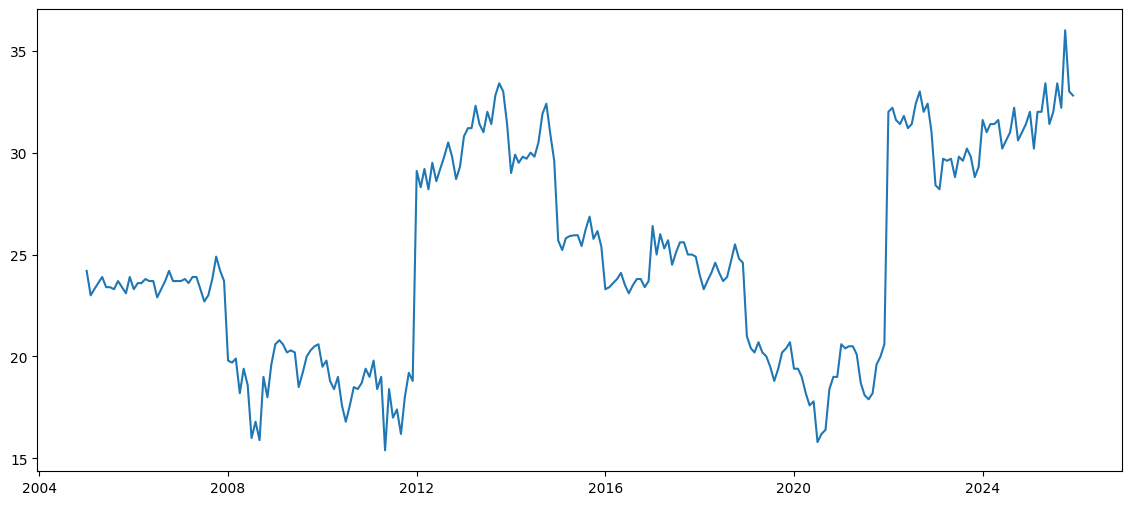

In [34]:
plt.figure(figsize=(14,6))
plt.plot(suhu['tahun'],suhu['suhu']); plt.show()

## plot ACF dan PACF

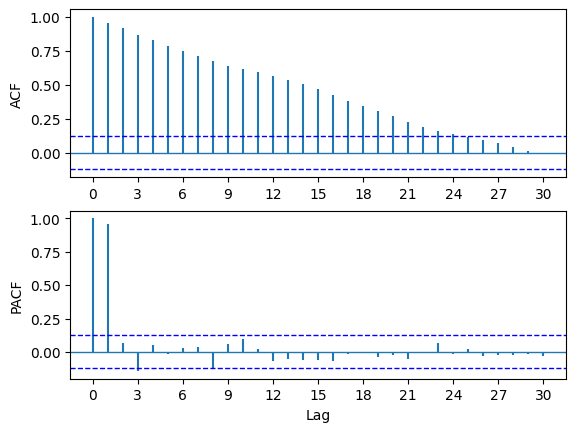

In [19]:
acf_pacf_fig(suhu['suhu'], both=True, lag=30)

## Cek Stasioner Data Suhu

### Uji ADF (kestasioneran dalam nilai tengah)
Hipotesis yang digunakan dalam uji ADF adalah


$H_0$ menyatakan deret tidak stasioner

$H_1$ menyatakan deret stasioner.

Kriteria keputusan: Tolak $H_0$ jika p-value < 0.05

In [20]:
# uji unit-root Augmented Dickey Fuller
from statsmodels.tsa.stattools import adfuller

adfuller(suhu['suhu'])[1]

0.2820770094308047

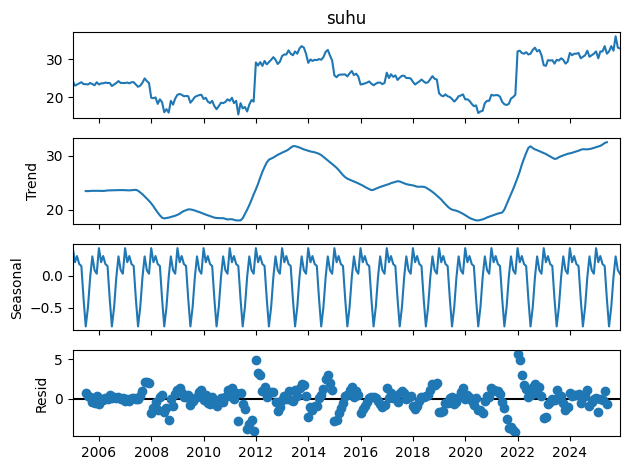

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose
suhu2=suhu.set_index('tahun')
result = seasonal_decompose(suhu2['suhu'], model='additive')
result.plot()
plt.show()

### Uji boxcox (kestasioneran dalan ragam)

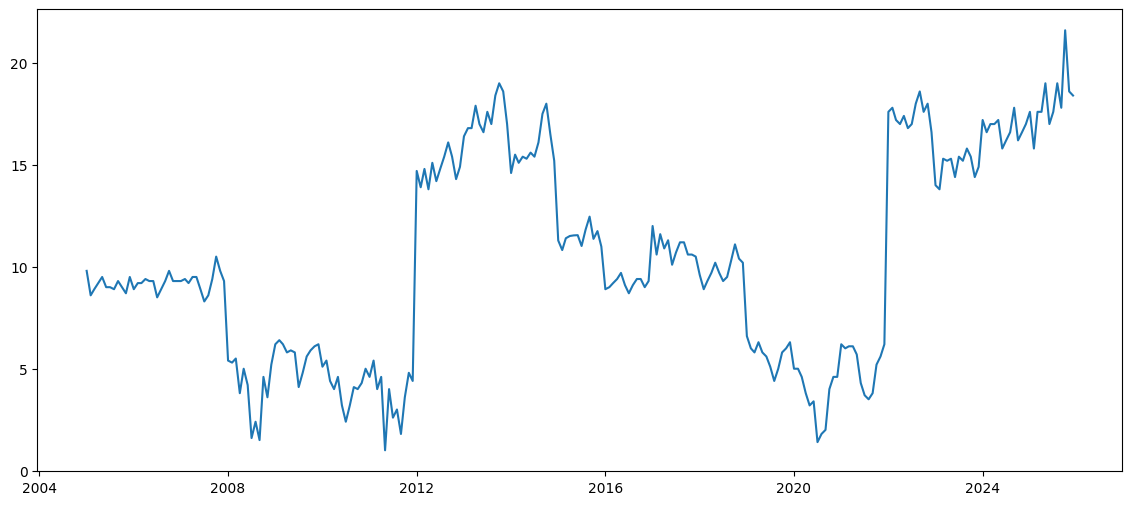

In [24]:
# Transformasi kolom 'nao_index_cdas' agar bernilai positif
suhu['suhu_positive'] = suhu['suhu'] - suhu['suhu'].min() + 1

# Plot data baru
plt.figure(figsize=(14,6))
plt.plot(suhu['tahun'],suhu['suhu_positive']); plt.show()

In [26]:
from scipy.stats import boxcox,  boxcox_llf
data,lambda_fit,ci=boxcox(suhu['suhu_positive'], alpha=0.05)

print(f'nilai lambda: ',lambda_fit)
print(f'interval kepercayaan lambda:', ci)

nilai lambda:  0.6295330041267352
interval kepercayaan lambda: (0.41603511606079374, 0.8539090589954563)


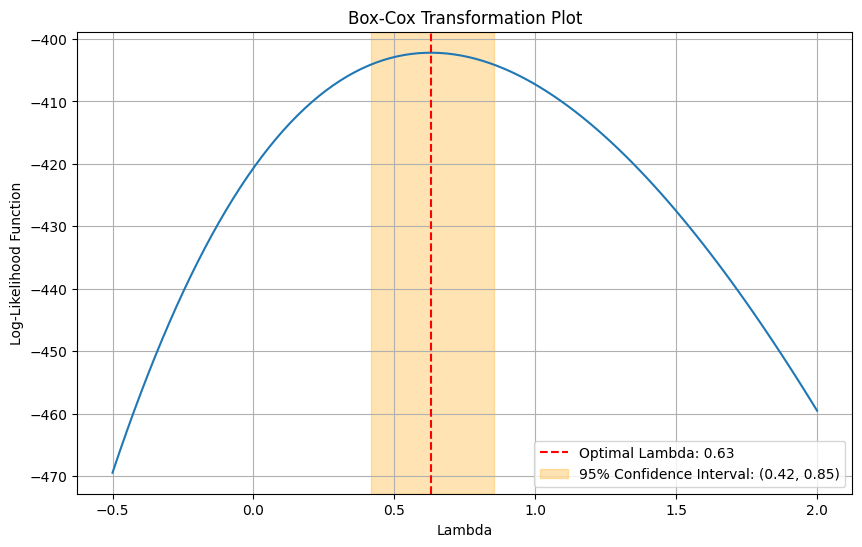

In [28]:
# Generate a range of lambda values
import numpy as np
import matplotlib.pyplot as plt

lambdas = np.linspace(-0.5, 2, 100)

# Calculate log-likelihood for each lambda
llf = [boxcox_llf(l, suhu['suhu_positive']) for l in lambdas]

plt.figure(figsize=(10, 6))
plt.plot(lambdas, llf)
plt.axvline(lambda_fit, color='r', linestyle='--', label=f'Optimal Lambda: {lambda_fit:.2f}')
plt.axvspan(ci[0], ci[1], color='orange', alpha=0.3, label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})')
plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend(); plt.grid(True); plt.show()